In [1]:
import math
gamma_value_int = math.gamma(5)


SERIES SYSTEM OF EXPONENTIAL COMPS

System expected MTTF is: <bound method SeriesSystem.MTTF_s of SeriesSystem(name=test_series_sys, state=1, num_components=3)>


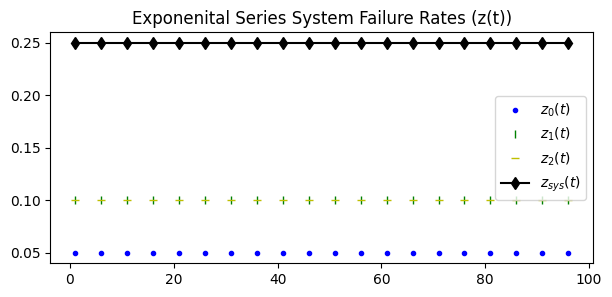

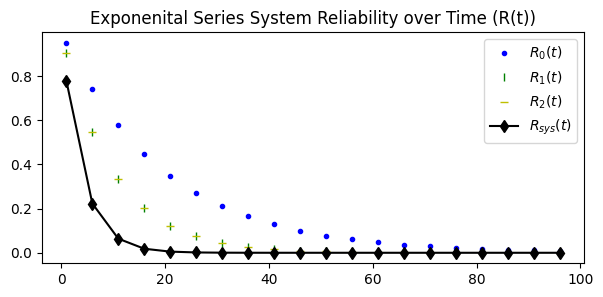

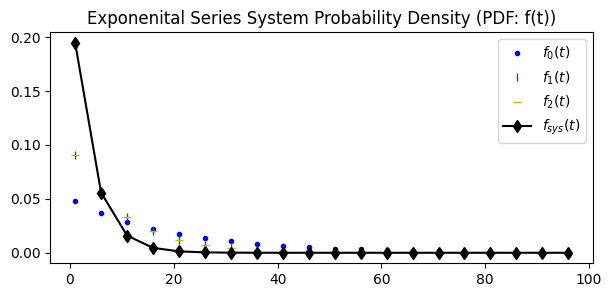

In [ ]:
_

System expected MTTF is: <bound method SeriesSystem.MTTF_s of SeriesSystem(name=test_series_sys, state=1, num_components=3)>


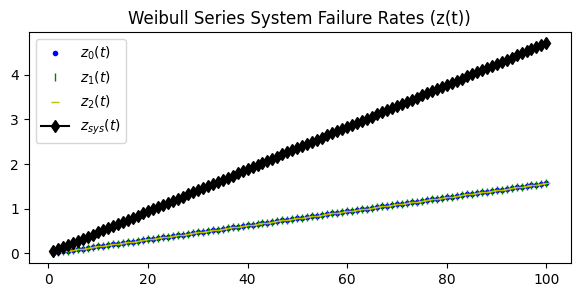

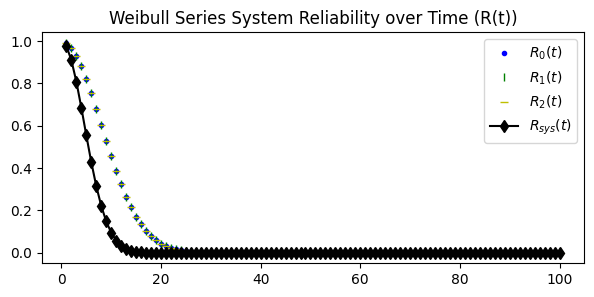

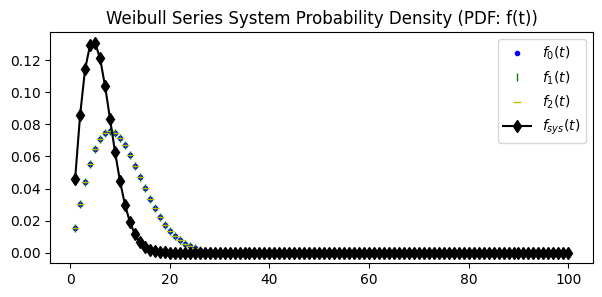

In [11]:
from sympy import Symbol, integrate
from system_objects.series_system import SeriesSystem
from component_objects.component_weibull import WeibullComponent 

import matplotlib.pyplot as plt
import numpy as np

# initialize exponential comps
num_comps = 3
MTTF = [10 for _ in range(num_comps)]
# MTTF[0] = 20
comps = [WeibullComponent(name="f{i+1}", MTTF= MTTF[i], MTTR=1, shape=2) for i in range(num_comps)]

# initialize a system with the comps 
sys = SeriesSystem("test_series_sys", comps)

# plotting settings
t = np.arange(1, 101, 1)   # <-- 1D array
shapes = ['.', '|', '_', 'd']
colors = ['b', 'g', 'y', 'k']

# plot the analytical z_s for each component and the system 
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.z_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$z_{i}(t)$")
plt.plot(t, sys.z_s(t), color=colors[-1], marker = shapes[-1], label= r"$z_{sys}(t)$")
plt.title("Weibull Series System Failure Rates (z(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.R_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$R_{i}(t)$")
plt.plot(t, sys.R_s(t), color=colors[-1], marker = shapes[-1], label= r"$R_{sys}(t)$")
plt.title("Weibull Series System Reliability over Time (R(t))")
plt.legend()

# plot the analytical R_s for each component in the system
plt.figure(figsize=(7,3))
for i,c in enumerate(comps):
    plt.plot(t, c.f_t(t), marker = shapes[i], color = colors[i], linestyle='', label = fr"$f_{i}(t)$")
plt.plot(t, sys.f_s(t), color=colors[-1], marker = shapes[-1], label= r"$f_{sys}(t)$")
plt.title("Weibull Series System Probability Density (PDF: f(t))")
plt.legend()

#print estimated MTTF
print(f"System expected MTTF is: {sys.MTTF_s}")

Simulate a few steps of series system operation

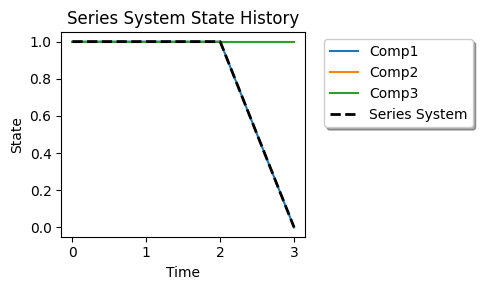

In [16]:
from system_objects.series_system import SeriesSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 10, MTTR= 3) for i in range(3)]

# create a series system with these components
system = SeriesSystem(name="Series System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 3, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.show()

Initialize a Series System and Simulate Operation

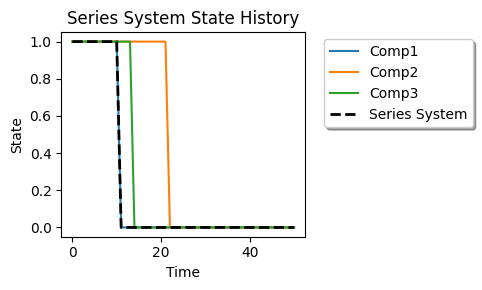

In [22]:
from system_objects.series_system import SeriesSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 10, MTTR= 3) for i in range(3)]

# create a series system with these components
system = SeriesSystem(name="Series System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 50, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.show()

Initialize a Parallel System and Simulate Operation

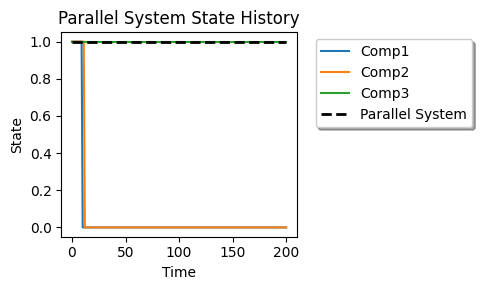

In [13]:
from system_objects.parallel_system import ParallelSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(3)]

# create a parallel system with these components
system = ParallelSystem(name="Parallel System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)

Initialize a k-out-of-N system

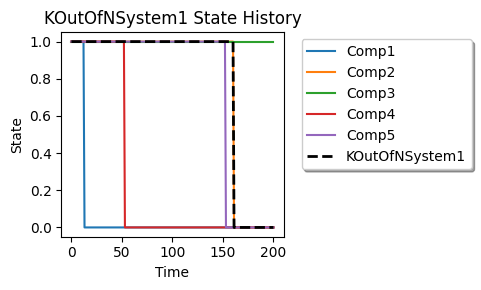

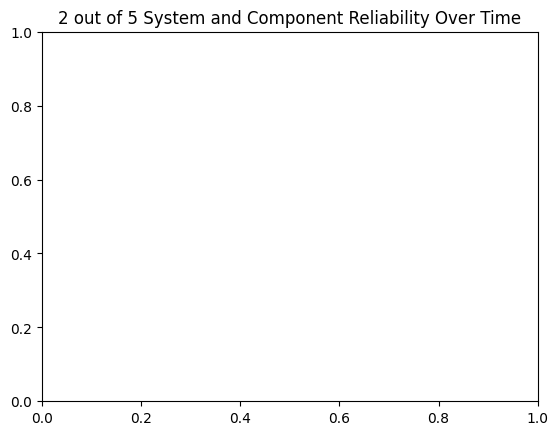

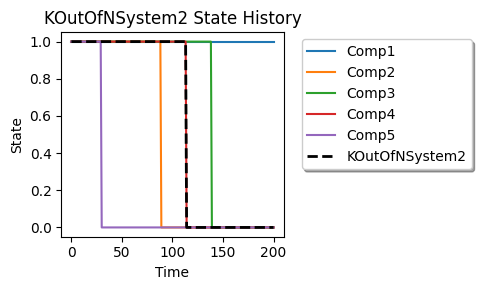

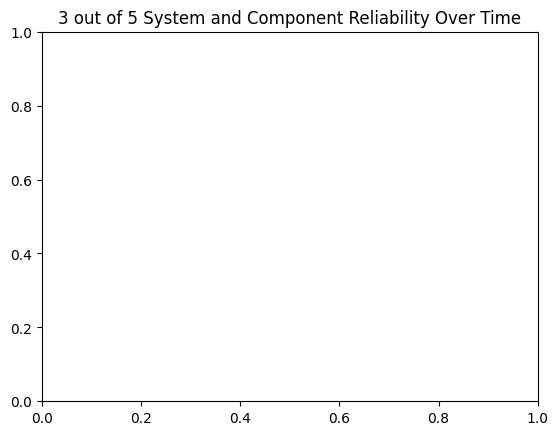

In [14]:
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(5)]
comps2 = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(5)]

# create a k-out-of-n system with these components
system = KOutOfNSystem(name="KOutOfNSystem1", components=comps, k=2)    # 2 out of 5
system2 = KOutOfNSystem(name="KOutOfNSystem2", components=comps2, k=3)    # 3 out of 5

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 1)
system2.simulate(t_end = 200, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.title("2 out of 5 System and Component Reliability Over Time")
plt.show()

plt.figure(figsize=(5, 3))
system2.plot_history(plot_comps=True)
plt.title("3 out of 5 System and Component Reliability Over Time")
plt.show()

Testing More Complex System of Systems

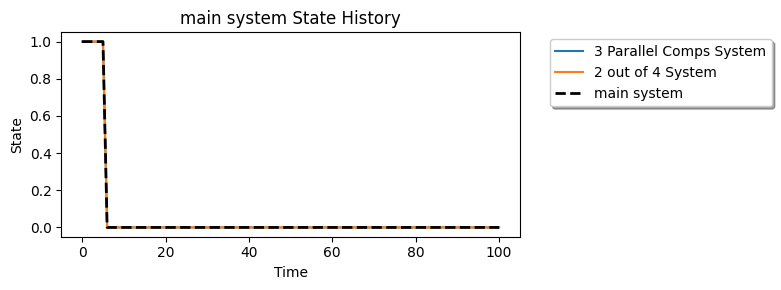

ValueError: Run simulate() before plotting.

<Figure size 500x300 with 0 Axes>

In [17]:
from system_objects.series_system import SeriesSystem
from system_objects.parallel_system import ParallelSystem
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt
import numpy as np

comps = [ExponentialComponent(name = f"Comp {i+1}", MTTF=20, MTTR=1) for i in range(7)]

sub_sys1 = ParallelSystem(name ="3 Parallel Comps System", components=comps[:3])
sub_sys2 = KOutOfNSystem(name ="2 out of 4 System", components = comps[3:], k=2)

sys = SeriesSystem(name="main system", components=[sub_sys1, sub_sys2])
sys.simulate(100, 1)

# plot all histories on seperate figures
plt.figure(figsize=(8, 3))
sys.plot_history(plot_comps=True)

plt.figure(figsize=(5, 3))
sub_sys1.plot_history(plot_comps=True)

plt.figure(figsize=(5, 3))
sub_sys2.plot_history(plot_comps=True)